# **Detección de fraude con tarjetas de crédito**

Para empezar comencemos con un resumen de la documentación de este dataset. Este dataset contiene 284,807 transacciones con tarjeta de crédito realizadas por clientes europeos en septiembre de 2013. Incluye 492 casos de fraude (0.172%), lo que lo convierte en un problema altamente desbalanceado. Las variables V1–V28 provienen de una transformación PCA para proteger la privacidad de los usuarios, mientras que Time, Amount y Class permanecen sin transformar. Nuestro objetivo principal es desarrollar modelos capaces de detectar transacciones fraudulentas.

In [21]:
#Importamos las librerías necesarias
import pandas as pd
import kagglehub
import os

In [23]:
#Cargamos el dataset
import os
df = pd.read_csv("creditcard.csv")
#path = "C:/path/to/csv/folder"
#df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Análisis Exploratorio de Datos

Iniciemos con una exploración de los datos 

In [37]:
df.shape


(284807, 31)

* 284,807 filas (cada fila es una transacción).

* 31 columnas, que equivalen a 30 variables numéricas y la variable objetivo ```Class```

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   Time    284807 non-null  float64 
 1   V1      284807 non-null  float64 
 2   V2      284807 non-null  float64 
 3   V3      284807 non-null  float64 
 4   V4      284807 non-null  float64 
 5   V5      284807 non-null  float64 
 6   V6      284807 non-null  float64 
 7   V7      284807 non-null  float64 
 8   V8      284807 non-null  float64 
 9   V9      284807 non-null  float64 
 10  V10     284807 non-null  float64 
 11  V11     284807 non-null  float64 
 12  V12     284807 non-null  float64 
 13  V13     284807 non-null  float64 
 14  V14     284807 non-null  float64 
 15  V15     284807 non-null  float64 
 16  V16     284807 non-null  float64 
 17  V17     284807 non-null  float64 
 18  V18     284807 non-null  float64 
 19  V19     284807 non-null  float64 
 20  V20     284807 non-null  float64 
 21

In [39]:
#Vamos a confirmar que no hay valores nulos en el dataset
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [40]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [41]:
#Observamos que la variable "Class" es una variable categórica que indica si la transacción es fraudulenta (1) o no (0)
#Cambiamos el tipo de dato de la variable "Class" a categórico
df['Class'] = df['Class'].astype('category')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   Time    284807 non-null  float64 
 1   V1      284807 non-null  float64 
 2   V2      284807 non-null  float64 
 3   V3      284807 non-null  float64 
 4   V4      284807 non-null  float64 
 5   V5      284807 non-null  float64 
 6   V6      284807 non-null  float64 
 7   V7      284807 non-null  float64 
 8   V8      284807 non-null  float64 
 9   V9      284807 non-null  float64 
 10  V10     284807 non-null  float64 
 11  V11     284807 non-null  float64 
 12  V12     284807 non-null  float64 
 13  V13     284807 non-null  float64 
 14  V14     284807 non-null  float64 
 15  V15     284807 non-null  float64 
 16  V16     284807 non-null  float64 
 17  V17     284807 non-null  float64 
 18  V18     284807 non-null  float64 
 19  V19     284807 non-null  float64 
 20  V20     284807 non-null  float64 
 21

Ahora revisamos la distribución de la variable objetivo ```Class```

In [42]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Este resultado nos muestra lo siguiente:

* 0 → ~0.99827 (99.827% transacciones normales)

* 1 → ~0.00172 (0.172% fraudes)

Por lo que nuestro dataset esta desbalanceado

Veamos la distribución de ```Amount```

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

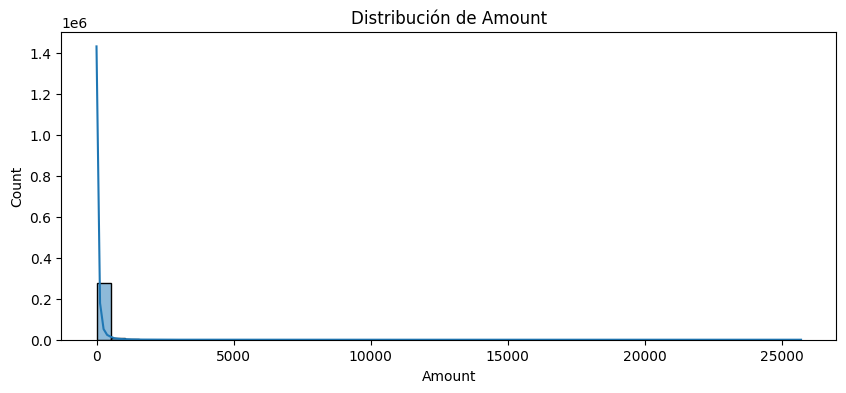

In [44]:
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribución de Amount")
plt.show()


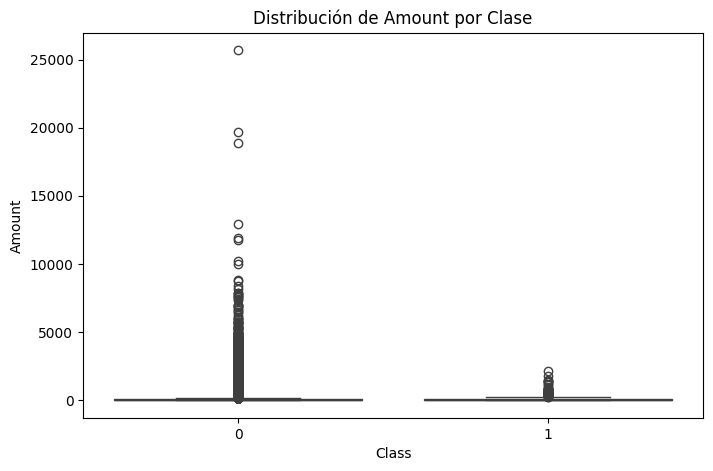

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title("Distribución de Amount por Clase")
plt.show()


In [46]:
df.groupby('Class')['Amount'].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Se pude observar que los montos que fueron detectados como fraude son más altos que los no se detectaron con fraude, sin embargo, observando la mediana, la mayoría de los montos son pequeños, incluso el máximo de montos es menor que las transacciones normales.

Con el gráfico de *Distribución de Amount por Clase* se puede ver más a detalle que las transacciones normales ```Class = 0```, hay muchos outliers, pero esto puede significar que hay montos legítimos desde muy pequeños hasta muy grandes, es decir, que muchas de las compras grandes son verdaderas y otro punto a destacar es que en el caso de los fraudes ```Class= 1``` rara vez son montos grandes, indicando que se hacen cargos pequeños para evitar sospechas.

Análisis de la variable ```Time```

 Según la documentación, la variable 'Tiempo' contiene los segundos transcurridos entre cada transacción y la primera transacción en el conjunto de datos. Recordemos que es un data set de 2 días.

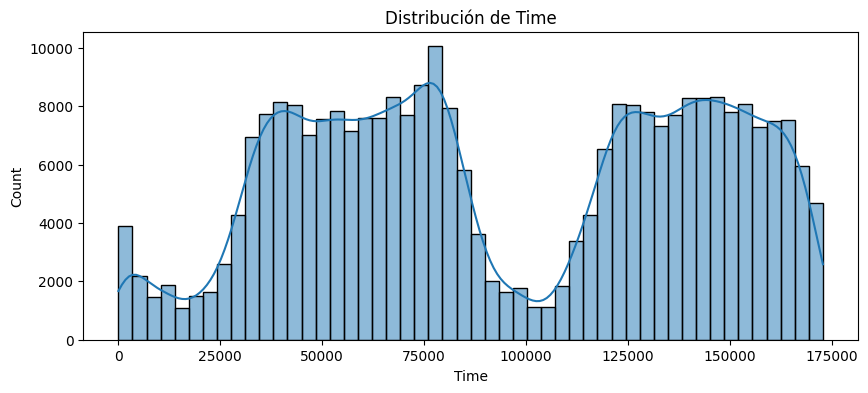

In [47]:
plt.figure(figsize=(10,4))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Distribución de Time")
plt.show()


Aunque la variable time es un contador acumulado, hay dos picos muy marcos, el que esta aproximadamente cerca de los 75,000 segundos y el que esta aproximadamente cerca de los 140,000 segundos, convirtamos estos segundos a horas, para facilitar la interpretación de los datos.

In [49]:
df['Hour'] = df['Time'] / 3600


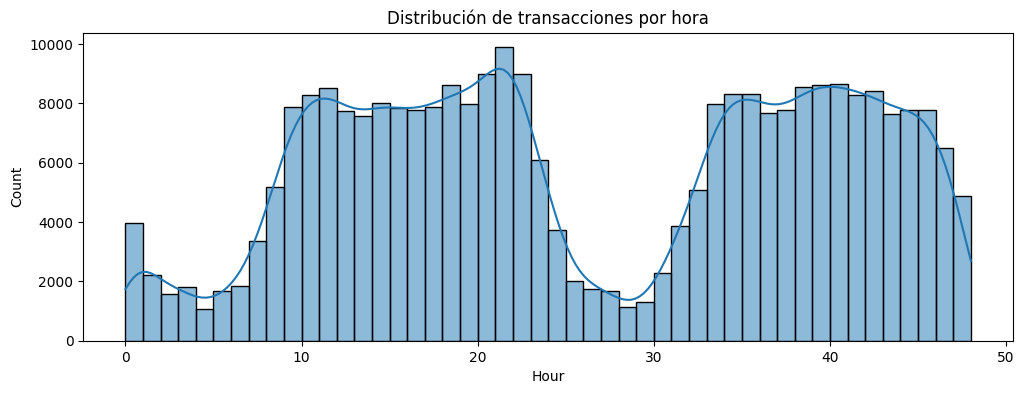

In [50]:
plt.figure(figsize=(12,4))
sns.histplot(df['Hour'], bins=48, kde=True)
plt.title("Distribución de transacciones por hora")
plt.show()

Ahora es más fácil ver que los picos están al rededor de las 20 horas y las 40 horas, y además hay una caída fuerte después de las 24 horas y las 30 horas.

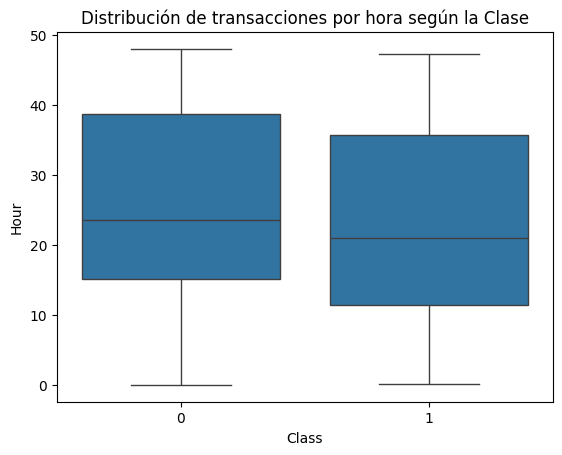

In [52]:
sns.boxplot(data=df, x='Class', y='Hour')
plt.title("Distribución de transacciones por hora según la Clase")
plt.show()

A simple vista no se puede llegar a una conclusión clara de si el tiempo es relevante para las transacciones fraudalentas, solo se observa que posiblemente los fraudes pueden ocurrir un poco antes de ciclo que las normales.

### Analicemos las correlaciones entre las variables

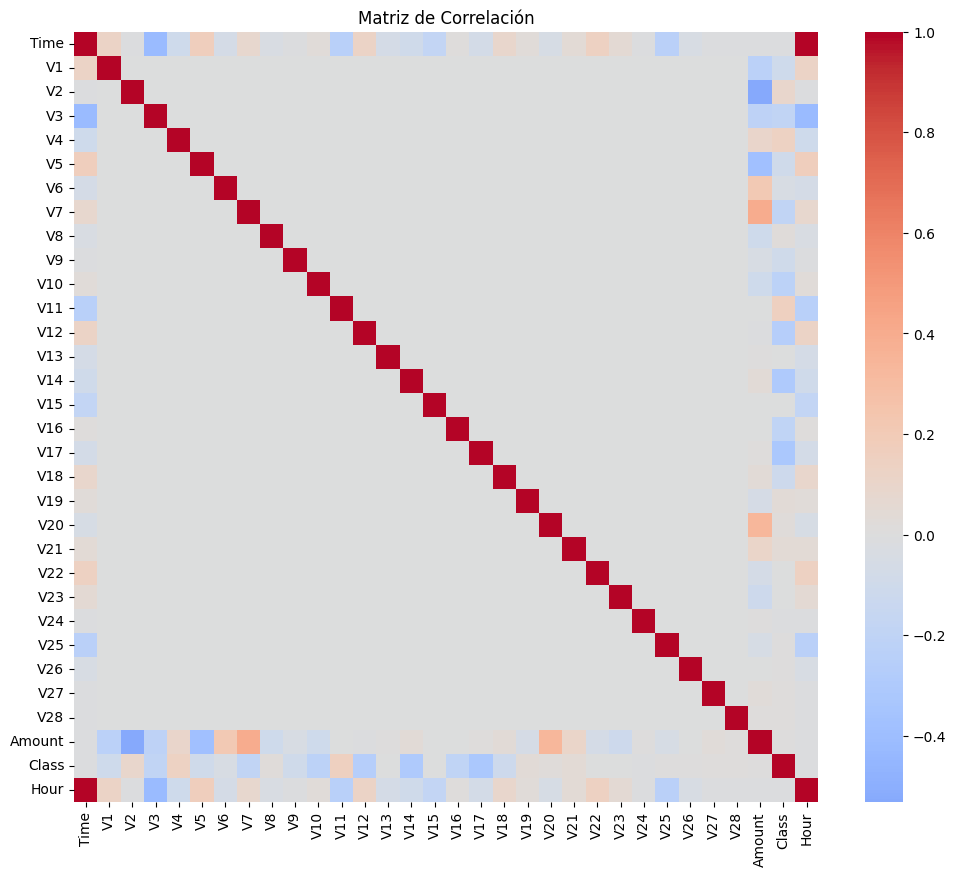

In [53]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()


Observemos que no hay fuertes correlaciones entre sí, por lo que ellos fraudes no se explican por sí solos con el monto y el tiempo.

Distribución de los ```features```

Recordemos que las variables V1, V2, … V28 son los componentes principales obtenidos con PCA, están escaladas, tienen media 0 y varianza 1.

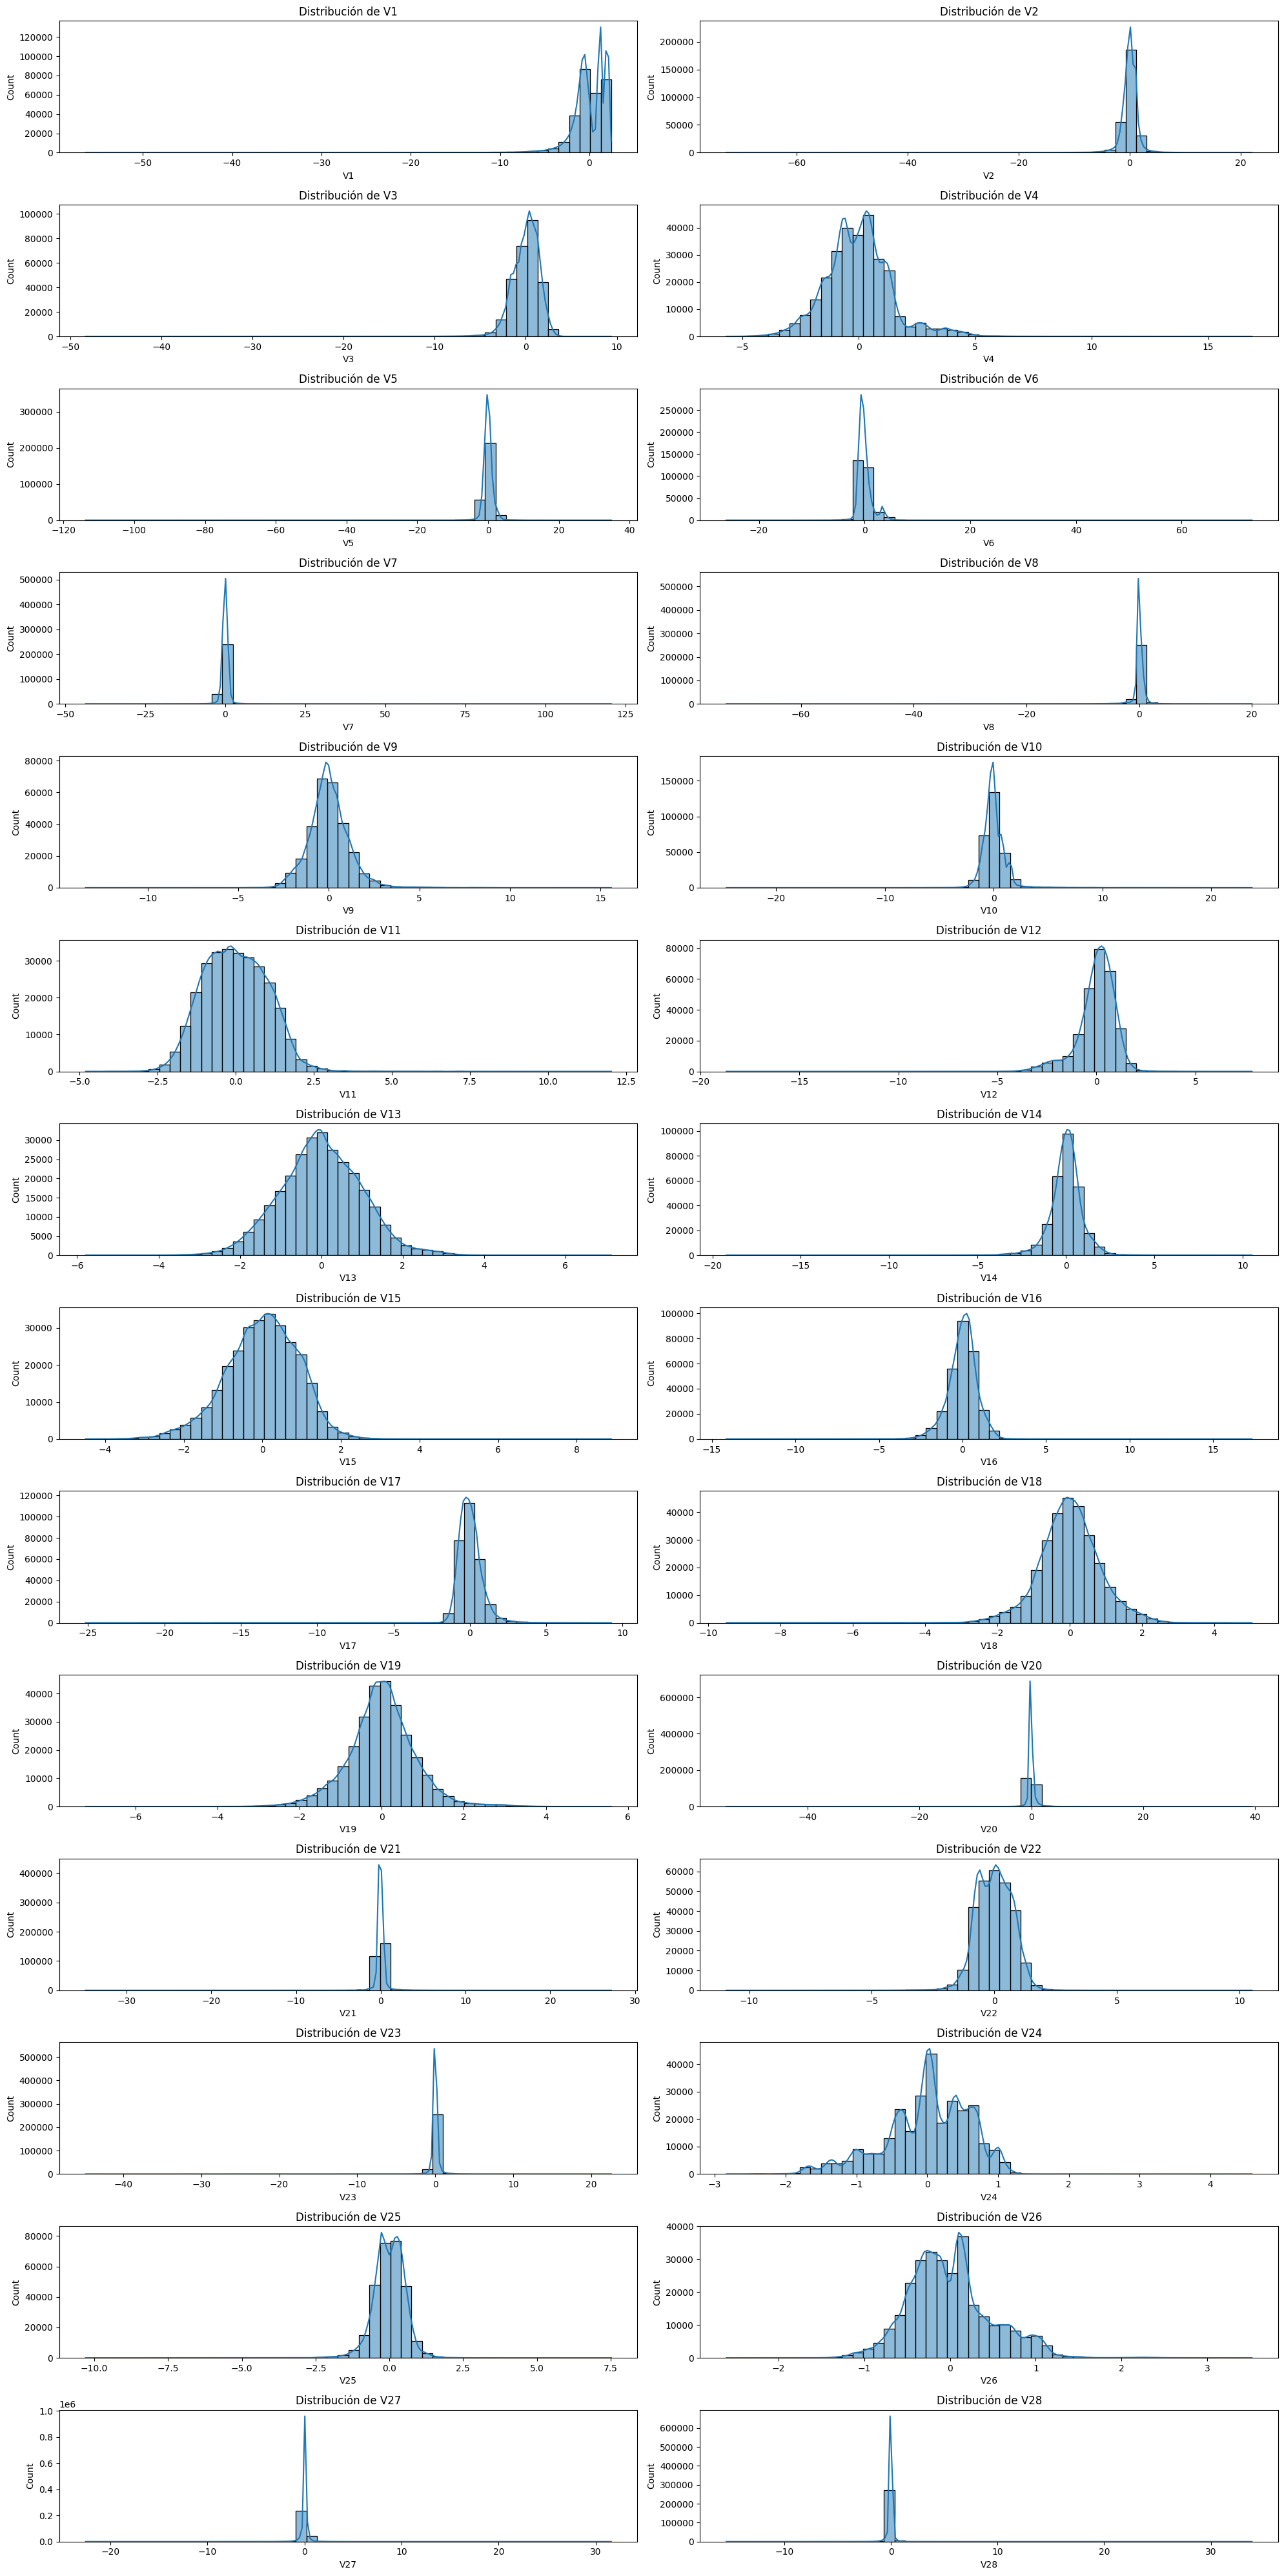

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [f"V{i}" for i in range(1, 29)]

plt.figure(figsize=(20, 40))

for i, col in enumerate(features, 1):
    plt.subplot(14, 2, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()


Muchas variables presentan forma de campana centrada en 0. Algunas componentes muestran valores extremos poco frecuentes, lo que podría indicar presencia de outliers o comportamientos atípicos. Analicemos algunas variables que presentaron estás característica de valores extremos, como:
* V10
* V12
* V14
* V17

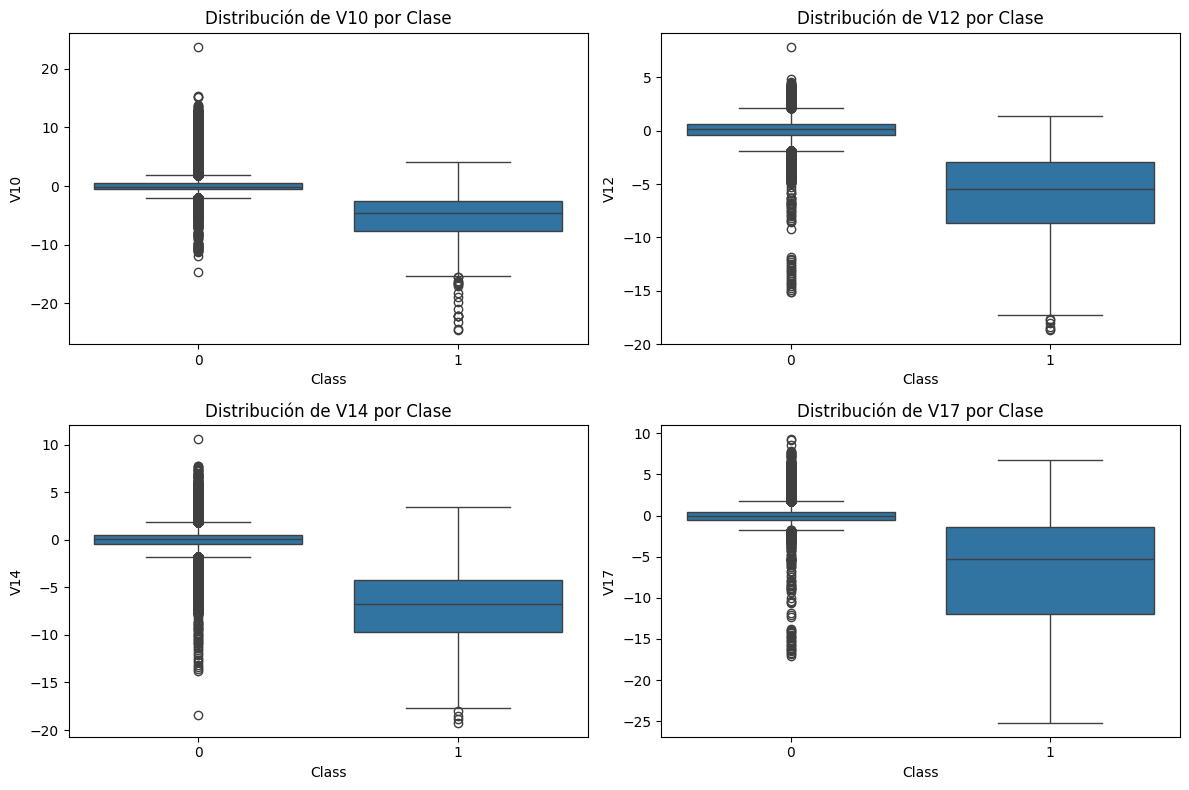

In [59]:
features = ['V10', 'V12', 'V14', 'V17']

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='Class', y=col)
    plt.title(f"Distribución de {col} por Clase")

plt.tight_layout()
plt.show()


Las variables V10, V12, V14 y V17 muestran diferencias significativas entre transacciones normales y fraudulentas. En particular, V10, V12 y V14 presentan valores considerablemente más negativos en la clase fraudulenta, mientras que V17 muestra valores más altos para esta misma clase. Por lo tanto, estas variables son altamente relevantes para los futuros modelos.

## Preprocesamiento de los datos

Hemos visto que las variables V1 a v28 ya vienen escaladas, no tenemos valores nulos y nuestra variable objetivo ya se convirtió a categórica, y también ya tenemos una nueva varible de Horas para facilitar su interpretación, sin embargo, nuestros modelos dependen de la escala, por lo que debemos de estandarizarlos.